In [1]:
import torch
import torch.utils.data
import os
import numpy as np
import time
from sklearn.metrics import roc_auc_score, roc_curve
import sys
from csv import writer
import random
from ad_clip.utils import get_rule, get_data_path, get_rule_tokens, get_object_info
from ad_clip.model import get_model
from ad_clip.data import ad_dataset, ad_obj_dataset
from csv import writer
from datetime import datetime
import argparse
from ad_clip import my_clip
import loralib as lora

from torch.utils.data import Subset
from torch.nn import functional as F

import open_clip

from ad_clip.loss import compute_negative_count_loss
import matplotlib.pyplot as plt

from PIL import Image

def set_random_seed(random_seed=123):
    torch.manual_seed(random_seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(random_seed)
    random.seed(random_seed)
    torch.cuda.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed) # multi-GPU
    print(f"Random seed {random_seed} is selected.")

def evaluate(args, model, tokenizer, pairs, test_good_dataset, test_sa_dataset, test_la_dataset):
    model.eval()
    sa_img_pred, la_img_pred = [], []

    good_probs = []
    la_probs = []
    sa_probs = []
    text_feature_list = []

    #Generating Image features
    if args.detection != 1:
        good_img_features = model.encode_image(test_good_dataset[:len(test_good_dataset)])
        #sa_img_features = model.encode_image(test_sa_dataset[:len(test_sa_dataset)])
        la_img_features = model.encode_image(test_la_dataset[:len(test_la_dataset)])
    else:
        good_img_features = model.encode_image(test_good_dataset[:len(test_good_dataset)][0])
        #sa_img_features = model.encode_image(test_sa_dataset[:len(test_sa_dataset)][0])

        la_img_features = model.encode_image(test_la_dataset[:len(test_la_dataset)][0])

    #Generating Text features
    for rule_idx, pair in enumerate(pairs):
        if args.text == 1:
            local_text = tokenizer(args.texts_for_rules[rule_idx]).to(device)
            global_text_feature = model.encode_text(pair)
            local_text_feature = model.encode_text(local_text)
            text_features = (global_text_feature + local_text_feature)
            text_feature_list.append(text_features)
        else:
            text_features = model.encode_text(pair)
            text_feature_list.append(text_features)
    #Computing probablity
    for rule_idx, pair in enumerate(pairs):
        text_features = text_feature_list[rule_idx]

        if args.detection != 1:
            pass
        elif args.detection ==1 and args.ris != 1:
            if args.mask == 1:
                if args.double_encoder != 1:
                    maksed_good_img_features = model.encode_image(test_good_dataset[:len(test_good_dataset)][1][:,rule_idx,:,:,:].squeeze(1))
                    #maksed_sa_img_features = model.encode_image(test_sa_dataset[:len(test_sa_dataset)][1][:,rule_idx,:,:,:].squeeze(1))
                    maksed_la_img_features = model.encode_image(test_la_dataset[:len(test_la_dataset)][1][:,rule_idx,:,:,:].squeeze(1))

                else:
                    maksed_good_img_features = model.encode_mask_image(test_good_dataset[:len(test_good_dataset)][1][:,rule_idx,:,:,:].squeeze(1))
                    #maksed_sa_img_features = model.encode_image(test_sa_dataset[:len(test_sa_dataset)][1][:,rule_idx,:,:,:].squeeze(1))
                    maksed_la_img_features = model.encode_mask_image(test_la_dataset[:len(test_la_dataset)][1][:,rule_idx,:,:,:].squeeze(1))

                good_img_features = (good_img_features + maksed_good_img_features)
                #sa_img_features = (sa_img_features + maksed_sa_img_features)/2
                la_img_features = (la_img_features + maksed_la_img_features)
            else:
                pass

        elif args.detection ==1 and args.ris == 1:
            if args.mask == 1:
                if args.double_encoder != 1:
                    maksed_good_img_features = model.encode_image(test_good_dataset[:len(test_good_dataset)][1][:,rule_idx,:,:,:].squeeze(1))
                    #maksed_sa_img_features = model.encode_image(test_sa_dataset[:len(test_sa_dataset)][1][:,rule_idx,:,:,:].squeeze(1))
                    maksed_la_img_features = model.encode_image(test_la_dataset[:len(test_la_dataset)][1][:,rule_idx,:,:,:].squeeze(1))

                else:
                    maksed_good_img_features = model.encode_mask_image(test_good_dataset[:len(test_good_dataset)][1][:,rule_idx,:,:,:].squeeze(1))
                    #maksed_sa_img_features = model.encode_image(test_sa_dataset[:len(test_sa_dataset)][1][:,rule_idx,:,:,:].squeeze(1))
                    maksed_la_img_features = model.encode_mask_image(test_la_dataset[:len(test_la_dataset)][1][:,rule_idx,:,:,:].squeeze(1))
                good_img_features = (good_img_features + maksed_good_img_features)
                #sa_img_features = (sa_img_features + maksed_sa_img_features)/2
                la_img_features = (la_img_features + maksed_la_img_features)
            else:
                pass
    


        good_img_features /= good_img_features.norm(dim=-1, keepdim=True)
        #sa_img_features /= sa_img_features.norm(dim=-1, keepdim=True)
        la_img_features /= la_img_features.norm(dim=-1, keepdim=True)

        text_features /= text_features.norm(dim=-1, keepdim=True)

        
        #Sample에 대한 good일 확률 계산. positive rule에 대한 similarity is considered as good sample probablity
        good_text_probs = (100.0 * good_img_features @ text_features.T).softmax(dim=-1)
        good_probs.append(good_text_probs[:,0])

        #sa_text_probs = (100.0 * sa_img_features @ text_features.T).softmax(dim=-1)
        #sa_probs.append(sa_text_probs[:,0])

        la_text_probs = (100.0 * la_img_features @ text_features.T).softmax(dim=-1)
        la_probs.append(la_text_probs[:,0])

    good_probs = torch.stack(good_probs, dim=1)

    if args.score == "mean":
        good_probs = torch.mean(good_probs, dim=1)
    elif args.score == "min":
        good_probs = torch.min(good_probs, dim=1).values
    elif args.score == "max":
        good_probs = torch.max(good_probs, dim=1).values
    elif args.score == "median":
        good_probs = torch.median(good_probs, dim=1).values

    #sa_probs = torch.stack(sa_probs, dim=1)
    #sa_probs = torch.mean(sa_probs, dim=1)

    #print(la_probs.shape)
    la_probs = torch.stack(la_probs, dim=1)
    
    if args.score == "mean":
        la_probs = torch.mean(la_probs, dim=1)
    elif args.score == "min":
        la_probs = torch.min(la_probs, dim=1).values
    elif args.score == "max":
        la_probs = torch.max(la_probs, dim=1).values
    elif args.score == "median":
        la_probs = torch.median(la_probs, dim=1).values
    

    #sa_img_pred = torch.cat((good_probs, sa_probs)).detach().cpu().numpy()
    la_img_pred = torch.cat((good_probs, la_probs)).detach().cpu().numpy()

    #sa_labels = [1 for i in range(len(good_probs))] + [0 for i in range(len(sa_probs))]
    #la_labels = [1 for i in range(len(good_probs))] + [0 for i in range(len(la_probs))]
    la_labels = [1 for i in range(len(good_probs))] + [0 for i in range(len(la_probs))]
    #sa_auc = roc_auc_score(y_true=sa_labels, y_score=sa_img_pred)
    la_auc = roc_auc_score(y_true=la_labels, y_score=la_img_pred)
    #print(f"Pred: {sa_img_pred}")
    #print(f"Label: {sa_labels}")

    """
    new_information = [sa_auc, la_auc, list(sa_img_pred), sa_labels, list(la_img_pred), la_labels]
    col_names = ['sa', 'la', 'sa_img_pred', 'sa_labels', 'la_img_pred', 'la_labels']
    file_name = 'record.csv'

    if not os.path.exists(file_name):
        with open(file_name, 'w') as record:
            writer_object = writer(record)
            writer_object.writerow(col_names)
            record.close()

    with open(file_name, 'a') as record:
        writer_object = writer(record)
        writer_object.writerow(new_information)
        record.close()
    """
    sa_auc = 0
    return sa_auc, la_auc

def valid(args, model, tokenizer, pairs, valid_dataloader):
    model.eval()
    loss_sum = 0
    
    if args.detection != 1:
        for batch, img in enumerate(valid_dataloader):
            total_loss = 0
            for pair in pairs:
                logits_per_image, logits_per_text, loss = model(img, pair, return_loss=True)
                total_loss += loss
            loss_sum+=total_loss.detach()

    elif args.detection==1 and args.ris != 1:
        for batch, img in enumerate(valid_dataloader):
            total_loss = 0
            raw_image, masked_image = img
            global_image_feature = model.encode_image(raw_image)

            for rule_idx, pair in enumerate(pairs):

                if args.mask == 1:
                    masked_image_for_rule = masked_image[:,rule_idx,:,:,:].squeeze(1)
                    if args.double_encoder != 1:
                        masked_image_feature = model.encode_image(masked_image_for_rule)
                    else:
                        masked_image_feature = model.encode_mask_image(masked_image_for_rule)
                    image_feature = (global_image_feature + masked_image_feature)
                else:
                    image_feature = model.encode_image(raw_image)
                
                if args.text == 1:
                    local_text = tokenizer(args.texts_for_rules[rule_idx]).to(device)
                    global_text_feature = model.encode_text(pair)
                    local_text_feature = model.encode_text(local_text)
                    text_feature = (global_text_feature + local_text_feature)
                else:
                    text_feature = model.encode_text(pair)

                
                loss = model.clip_loss(image_feature, text_feature, model.clip.logit_scale.exp())
                total_loss += loss
            loss_sum+=total_loss.detach()

    elif args.detection==1 and args.ris == 1:
        for batch, img in enumerate(valid_dataloader):
            total_loss = 0
            raw_image, masked_image, meta = img
            for rule_idx, pair in enumerate(pairs):

                if args.mask == 1:
                    global_image_feature = model.encode_image(raw_image)
                    masked_image_for_rule = masked_image[:,rule_idx,:,:,:].squeeze(1)

                    if args.double_encoder != 1:
                        masked_image_feature = model.encode_image(masked_image_for_rule)
                    else:
                        masked_image_feature = model.encode_mask_image(masked_image_for_rule)
                    image_feature = (global_image_feature + masked_image_feature)
                else:
                    image_feature = model.encode_image(raw_image)
                
                if args.text == 1:
                    local_text = tokenizer(args.texts_for_rules[rule_idx]).to(device)
                    global_text_feature = model.encode_text(pair)
                    local_text_feature = model.encode_text(local_text)
                    text_feature = (global_text_feature + local_text_feature)
                else:
                    text_feature = model.encode_text(pair)

                meta_feature_for_rule = meta[:, rule_idx]
                    
                meta_image_feature = torch.cat((meta_feature_for_rule, image_feature), dim=1)
                meta_image_feature = meta_projecter(meta_image_feature)
                loss = model.clip_loss(meta_image_feature, text_feature, model.clip.logit_scale.exp())
                total_loss += loss
            loss_sum+=total_loss.detach()

    if args.log == 1:
        print(f"Valid Loss: {loss_sum/len(valid_dataloader)}")
    return loss_sum



def train(args, model, tokenizer, pairs, train_dataloader, valid_dataloader, test_good_dataset, test_sa_dataset, test_la_dataset, optimizer, epoch=1, tag="default"):
    start = time.time()
    best_la_auc = 0

    for i in range(epoch):
        loss_sum = 0
        neg_loss_sum = 0

        
        if i % 10 == 0:
            pass
            #val_loss = valid(args, model, tokenizer, pairs, valid_dataloader)

        sa_auc, la_auc = evaluate(args, model, tokenizer, pairs, test_good_dataset, test_sa_dataset, test_la_dataset)
        if args.log:
            print(f"[Test ROC-AUC]  -  SA: {sa_auc:.5f},  LA: {la_auc:.5f}")
        if la_auc > best_la_auc:
            if la_auc > 0.9 and (la_auc-best_la_auc) >= 0.01:
                #saved_path = save_model(args, model=model, performance_metric=la_auc, epoch=i, tag=tag, base_directory="./pretrained")
                pass
            best_la_auc = la_auc
        
        model.train()
        if args.detection != 1 and args.ris != 1: 
            for idx, img in enumerate(train_dataloader):
                total_loss = 0
                for pair in pairs:
                    logits_per_image, logits_per_text, loss = model(img, pair, return_loss=True)
                    total_loss += loss
                
                if not args.default:
                    total_loss.backward()
                    optimizer.step()
                    optimizer.zero_grad()
                else:
                    pass

                loss_sum+=total_loss.detach()
            if args.log==1:
                print(f"Epoch: {i+1} | Loss: {loss_sum/len(train_dataloader)}")

        elif args.detection ==1 and args.ris != 1:
            for idx, img in enumerate(train_dataloader):
                raw_image, masked_image = img

                total_loss = 0
                total_neg_loss = 0
                global_image_feature = model.encode_image(raw_image)
                for rule_idx, pair in enumerate(pairs):
                    
                    if args.mask==1:
                        masked_image_for_rule = masked_image[:,rule_idx,:,:,:].squeeze(1)

                        if args.double_encoder != 1:
                            masked_image_feature = model.encode_image(masked_image_for_rule)
                        else:
                            masked_image_feature = model.encode_mask_image(masked_image_for_rule)
                        image_feature = (global_image_feature + masked_image_feature)
                    else:
                        image_feature = global_image_feature


                    if args.text ==1:
                        local_text = tokenizer(args.texts_for_rules[rule_idx]).to(device)
                        global_text_feature = model.encode_text(pair)
                        local_text_feature = model.encode_text(local_text)
                        text_feature = (global_text_feature + local_text_feature)
                    else:
                        text_feature = model.encode_text(pair)

                    loss = model.clip_loss(image_feature, text_feature, model.clip.logit_scale.exp())
                    
                    negative_loss = 0
                    if args.neg_loss != 0:  
                        num_img = image_feature.shape[0]
                        if num_img == 1:
                            negative_loss = compute_negative_count_loss(image_feature, text_feature[0], text_feature[1:])
                        else:
                            for num_img_idx in range(num_img):
                                negative_loss += compute_negative_count_loss(image_feature[num_img_idx], text_feature[0], text_feature[1:])
                            negative_loss /= num_img
                        
                    else:
                        negative_loss = 0
                        

                    total_loss += (loss + args.neg_loss * negative_loss)

                    total_neg_loss += negative_loss

                if not args.default:
                    total_loss.backward()
                    optimizer.step()
                    optimizer.zero_grad()
                else:
                    pass

                loss_sum+=total_loss.detach().cpu().numpy()

                if args.neg_loss != 0:
                    neg_loss_sum += total_neg_loss.detach().cpu().numpy()
                else:
                    neg_loss_sum += 0

            if args.log == 1:
                print(f"Epoch: {i} | Loss: {loss_sum/len(train_dataloader)}  | Negative Loss: {neg_loss_sum/len(train_dataloader)}")
                
        elif args.detection ==1 and args.ris == 1:
            print("Meta feature")
            #meta_projecter = meta_projecter.to(device)
            
            for idx, img in enumerate(train_dataloader):
                raw_image, masked_image, meta = img
                total_loss = 0
                total_neg_loss = 0
                global_image_feature = model.encode_image(raw_image)
                
                for rule_idx, pair in enumerate(pairs):
                    if args.mask==1:
                        masked_image_for_rule = masked_image[:,rule_idx,:,:,:].squeeze(1)
                        if args.double_encoder != 1:
                            masked_image_feature = model.encode_image(masked_image_for_rule)
                        else:
                            masked_image_feature = model.encode_mask_image(masked_image_for_rule)
                        image_feature = (global_image_feature + masked_image_feature)
                    else:
                        
                        image_feature = global_image_feature


                    if args.text ==1:
                        local_text = tokenizer(args.texts_for_rules[rule_idx]).to(device)
                        global_text_feature = model.encode_text(pair)
                        local_text_feature = model.encode_text(local_text)
                        text_feature = (global_text_feature + local_text_feature)
                    else:
                        text_feature = model.encode_text(pair)

                    meta_feature_for_rule = meta[:, rule_idx]
                    
                    meta_image_feature = torch.cat((meta_feature_for_rule, image_feature), dim=1)
                    meta_image_feature = meta_projecter(meta_image_feature)
                    
                    loss = model.clip_loss(meta_image_feature, text_feature, model.clip.logit_scale.exp())
                    
                    negative_loss = 0
                    if args.neg_loss != 0:  
                        num_img = image_feature.shape[0]
                        if num_img == 1:
                            negative_loss = compute_negative_count_loss(image_feature, text_feature[0], text_feature[1:])
                        else:
                            for num_img_idx in range(num_img):
                                negative_loss += compute_negative_count_loss(image_feature[num_img_idx], text_feature[0], text_feature[1:])
                            negative_loss /= num_img
                        
                    else:
                        negative_loss = 0
                        

                    total_loss += (loss + args.neg_loss * negative_loss)

                    total_neg_loss += negative_loss

                if not args.default:
                    total_loss.backward()
                    optimizer.step()
                    optimizer.zero_grad()
                    meta_optimizer.step()
                    meta_optimizer.zero_grad()
                else:
                    pass

                loss_sum+=total_loss.detach().cpu().numpy()

                if args.neg_loss != 0:
                    neg_loss_sum += total_neg_loss.detach().cpu().numpy()
                else:
                    neg_loss_sum += 0

            if args.log == 1:
                print(f"Epoch: {i} | Loss: {loss_sum/len(train_dataloader)}  | Negative Loss: {neg_loss_sum/len(train_dataloader)}")

        
    end = time.time()

    print(f"Time consumption: {end-start}")
    print(f"Best LA AUC: {best_la_auc}")

/home/seungeon/.conda/envs/la/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
class param:
    def __init__(self):
        self.epoch = 100
        self.gpu_number = "3"
        self.data_name = "breakfast"
        self.model_name = 'ViT-B-32'
        self.pretrained_name = 'laion2b_s34b_b79k'
        self.detection = True
        self.preprocess = True
        self.num_rule = 0
        self.objects_names = []
        self.objects_for_rules = []
        self.mask = True
        self.text = True
        self.score = "min"
        self.double_encoder = True
        self.seed = 2024
        self.default = False
        self.foundation = "CLIP"
        self.lora = 1
        self.pretrained_count_path = None
        self.lr = 1e-4
        self.batch_size = 6
        self.shuffle = True
        self.ris = 0
        self.log = True
        self.neg_loss = 0
        self.few_shot = True
        self.shot = 5

In [4]:
args = param()

os.environ["CUDA_VISIBLE_DEVICES"] = args.gpu_number


In [4]:
args = param()

os.environ["CUDA_VISIBLE_DEVICES"] = args.gpu_number

set_random_seed(random_seed=args.seed)

print(f"Torch version: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"{device} is loaded for process")

Random seed 2024 is selected.
Torch version: 2.2.0+cu121
cuda is loaded for process


In [5]:
object_names, objects_for_rules, texts_for_rules = get_object_info(args.data_name)
args.object_names = object_names
args.objects_for_rules = objects_for_rules
args.texts_for_rules = texts_for_rules
print(args)

my_model, preprocess, tokenizer, optimizer = get_model(args, model_name=args.model_name, pretrained_name=args.pretrained_name, default=args.default, double_encoder=args.double_encoder)
#my_model.load_state_dict(torch.load(args.model_path), strict=False)

my_model = my_model.to(device)

print("Tokenizing rules")
if args.num_rule == 0:
    rules_for_data = get_rule(data_name = args.data_name, rule_idxs="max")
else:
    rules_for_data = get_rule(data_name = args.data_name, rule_idxs=[i for i in range(args.num_rule)])
rule_token_pairs = get_rule_tokens(rules=rules_for_data, tokenizer=tokenizer, device=device)

data_path_dict = get_data_path(args.data_name, log_option=False)

if not args.detection:
    test_good_dataset = ad_dataset(data_path_dict, 'test_good_path', preprocess=preprocess, level=3, device=device)
    test_sa_dataset = ad_dataset(data_path_dict, 'test_sa_path', preprocess=preprocess, level=3, device=device)
    test_la_dataset = ad_dataset(data_path_dict, 'test_la_path', preprocess=preprocess, level=3, device=device)

else:

    if not args.preprocess:
        sys.exit("Beforing evaluating model, please run make_detection.py and train.py. \nYou must have pretrained model and preprocessed dataloader.")
    else:
        data_base_path_dict = {
            "breakfast" : "/data/seungeon/orig/breakfast_box",
            "juice_bot" : "/data/seungeon/orig/juice_bottle",
            "pushpins" :"/data/seungeon/orig/pushpins",
            "screw_bag" : "/data/seungeon/orig/screw_bag",
            "splicing" : "/data/seungeon/orig/splicing_connectors",

            "banana_juice" : "/data/seungeon/orig/juice_bottle_banana",
            "cherry_juice" : "/data/seungeon/orig/juice_bottle_cherry",
            "orange_juice" : "/data/seungeon/orig/juice_bottle_orange",

            "blue_splicing" : "/data/seungeon/orig/splicing_connector_blue_cable",
            "red_splicing" : "/data/seungeon/orig/splicing_connector_red_cable",
            "yellow_splicing" : "/data/seungeon/orig/splicing_connector_yellow_cable",

            #additional Visa dataset
            "pcb1" : "/data3/seungeon/data/image/visa/pcb1",
            "pcb2" : "/data3/seungeon/data/image/visa/pcb2",
            "pcb3" : "/data3/seungeon/data/image/visa/pcb3",
            "pcb4" : "/data3/seungeon/data/image/visa/pcb4",

            #additional MVTec AD dataset
            "cable": "/data3/seungeon/data/image/mvtec_ad/cable",
            "capsule": "/data3/seungeon/data/image/mvtec_ad/capsule",
            "transistor": "/data3/seungeon/data/image/mvtec_ad/transistor",
            }
        print("Loading datasets...", end="\r")
        base_save_path = data_base_path_dict[args.data_name]
        train_dataset = torch.load(os.path.join(base_save_path, "train.pt"))
        val_dataset = torch.load(os.path.join(base_save_path, 'val.pt'))
        test_good_dataset = torch.load(os.path.join(base_save_path, 'test_good.pt'))
        test_la_dataset = torch.load(os.path.join(base_save_path, 'test_la.pt'))
        test_sa_dataset = torch.load(os.path.join(base_save_path, 'test_sa.pt'))
        
if args.few_shot ==1:
    sampled_indices = random.sample(range(len(train_dataset)), args.shot)
    train_dataset = Subset(train_dataset, sampled_indices)

print(f"\n[Data Description]")
print(f"- Train: {len(train_dataset)}")
print(f"- Valid: {len(val_dataset)}")
print(f"- Test: {len(test_good_dataset)+len(test_la_dataset)}\n")
train_dataloader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=args.batch_size, shuffle=args.shuffle)#, drop_last=True)
val_dataloader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=args.batch_size, shuffle=args.shuffle)#, drop_last=True)

In my local computer


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 23.68 GiB of which 13.19 MiB is free. Process 1532096 has 22.29 GiB memory in use. Including non-PyTorch memory, this process has 1.37 GiB memory in use. Of the allocated memory 624.98 MiB is allocated by PyTorch, and 49.02 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [5]:
train(args, model=my_model, tokenizer=tokenizer, pairs=rule_token_pairs, train_dataloader=train_dataloader, valid_dataloader=val_dataloader, test_good_dataset=test_good_dataset, 
          test_sa_dataset=test_sa_dataset, test_la_dataset=test_la_dataset, optimizer=optimizer, epoch=50)

[Test ROC-AUC]  -  SA: 0.00000,  LA: 0.37302
Epoch: 0 | Loss: 7.210727691650391  | Negative Loss: 0.0
[Test ROC-AUC]  -  SA: 0.00000,  LA: 0.37550
Epoch: 1 | Loss: 7.1515936851501465  | Negative Loss: 0.0
[Test ROC-AUC]  -  SA: 0.00000,  LA: 0.38023
Epoch: 2 | Loss: 7.070011615753174  | Negative Loss: 0.0
[Test ROC-AUC]  -  SA: 0.00000,  LA: 0.38850
Epoch: 3 | Loss: 6.964701175689697  | Negative Loss: 0.0
[Test ROC-AUC]  -  SA: 0.00000,  LA: 0.40326
Epoch: 4 | Loss: 6.834587097167969  | Negative Loss: 0.0
[Test ROC-AUC]  -  SA: 0.00000,  LA: 0.42086
Epoch: 5 | Loss: 6.678511142730713  | Negative Loss: 0.0
[Test ROC-AUC]  -  SA: 0.00000,  LA: 0.44259
Epoch: 6 | Loss: 6.4970316886901855  | Negative Loss: 0.0
[Test ROC-AUC]  -  SA: 0.00000,  LA: 0.46917
Epoch: 7 | Loss: 6.290806293487549  | Negative Loss: 0.0
[Test ROC-AUC]  -  SA: 0.00000,  LA: 0.50496
Epoch: 8 | Loss: 6.061609268188477  | Negative Loss: 0.0
[Test ROC-AUC]  -  SA: 0.00000,  LA: 0.54347
Epoch: 9 | Loss: 5.811553478240967 

In [6]:
my_model.eval()

img_idx = 10

good_img_feature = my_model.encode_image(test_good_dataset[img_idx:img_idx+1][0])
good_img_path = test_good_dataset.img_paths[img_idx]
la_img_feature = my_model.encode_image(test_la_dataset[img_idx:img_idx+1][0])
la_img_path = test_la_dataset.img_paths[img_idx]
print(good_img_feature.shape, good_img_path)
print(la_img_feature.shape, la_img_path)

torch.Size([1, 512]) /data/seungeon/orig/breakfast_box/test/good/010.png
torch.Size([1, 512]) /data/seungeon/orig/breakfast_box/test/logical_anomalies/010.png


In [7]:
text_feature_list = []
good_probs = []
good_negative_probs = []
la_probs = []
la_negative_probs = []

for rule_idx, pair in enumerate(rule_token_pairs):
    if args.text == 1:
        local_text = tokenizer(args.texts_for_rules[rule_idx]).to(device)
        global_text_feature = my_model.encode_text(pair)
        local_text_feature = my_model.encode_text(local_text)
        text_features = (global_text_feature + local_text_feature)
        text_feature_list.append(text_features)
    else:
        text_features = my_model.encode_text(pair)
        text_feature_list.append(text_features)

In [8]:
for rule_idx, pair in enumerate(rule_token_pairs):
    text_features = text_feature_list[rule_idx]

    if args.mask == 1:
        if args.double_encoder != 1:
            maksed_good_img_features = my_model.encode_image(test_good_dataset[img_idx:img_idx+1][1][:,rule_idx,:,:,:].squeeze(1))
            #maksed_sa_img_features = model.encode_image(test_sa_dataset[:len(test_sa_dataset)][1][:,rule_idx,:,:,:].squeeze(1))
            maksed_la_img_features = my_model.encode_image(test_la_dataset[img_idx:img_idx+1][1][:,rule_idx,:,:,:].squeeze(1))

        else:
            maksed_good_img_features = my_model.encode_mask_image(test_good_dataset[img_idx:img_idx+1][1][:,rule_idx,:,:,:].squeeze(1))
            #maksed_sa_img_features = model.encode_image(test_sa_dataset[:len(test_sa_dataset)][1][:,rule_idx,:,:,:].squeeze(1))

            maksed_la_img_features = my_model.encode_mask_image(test_la_dataset[img_idx:img_idx+1][1][:,rule_idx,:,:,:].squeeze(1))
        good_img_features = (good_img_feature + maksed_good_img_features)
        #sa_img_features = (sa_img_features + maksed_sa_img_features)/2
        la_img_features = (la_img_feature + maksed_la_img_features)
    else:
        pass

    good_img_features /= good_img_features.norm(dim=-1, keepdim=True)
    #sa_img_features /= sa_img_features.norm(dim=-1, keepdim=True)
    la_img_features /= la_img_features.norm(dim=-1, keepdim=True)

    text_features /= text_features.norm(dim=-1, keepdim=True)

    good_text_probs = (100.0 * good_img_features @ text_features.T).softmax(dim=-1)
    good_probs.append(good_text_probs[:,0])
    good_negative_probs.append(good_text_probs[:,1:])

    la_text_probs = (100.0 * la_img_features @ text_features.T).softmax(dim=-1)
    la_probs.append(la_text_probs[:,0])
    la_negative_probs.append(la_text_probs[:,1:])

In [9]:
good_probs = torch.stack(good_probs, dim=1)
print(good_probs.detach().cpu().tolist()[0])
if args.score == "mean":
    good_probs_score = torch.mean(good_probs, dim=1)
elif args.score == "min":
    good_probs_score = torch.min(good_probs, dim=1).values
elif args.score == "max":
    good_probs_score = torch.max(good_probs, dim=1).values
elif args.score == "median":
    good_probs_score = torch.median(good_probs, dim=1).values
print(good_probs_score.detach().cpu().tolist()[0])

[0.9084416031837463, 0.9169148206710815, 0.7697923183441162, 0.8585016131401062, 0.7682955265045166, 0.8547593951225281, 0.43122953176498413]
0.43122953176498413


In [10]:
good_negative_probs = torch.stack(good_negative_probs)
good_negative_probs = good_negative_probs.squeeze(1)
good_img_probs = torch.cat([good_probs.T, good_negative_probs], dim=1)

<Axes: >

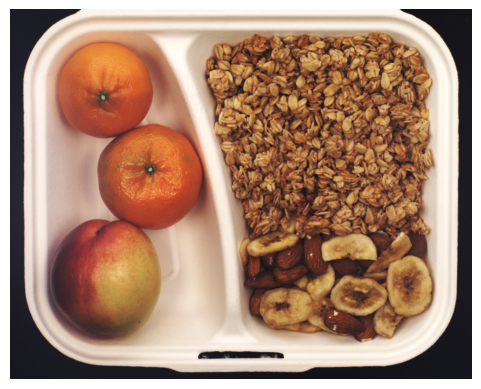

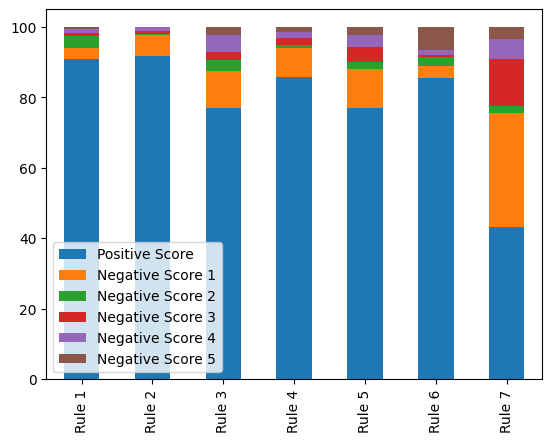

In [11]:
import pandas as pd

df = pd.DataFrame(good_img_probs.T.detach().cpu().numpy()).T
df.index = [f"Rule {i+1}" for i in range(len(df))]
df.columns = ["Positive Score"] + [f"Negative Score {i+1}" for i in range(len(df.columns)-1)]
df_total = df.copy()
df_total['Total'] = df_total.sum(axis=1)
for col in df_total.columns[:-1]:
    df_total[col] = df_total[col] / df_total['Total'] * 100


plt.imshow(Image.open(good_img_path))
plt.axis("off")

df_group_100 = df_total.drop('Total', axis=1)
df_group_100.plot(kind='bar', stacked=True)


In [12]:
la_probs = torch.stack(la_probs, dim=1)
print(la_probs.detach().cpu().tolist()[0])
if args.score == "mean":
    la_probs_score = torch.mean(la_probs, dim=1)
elif args.score == "min":
    la_probs_score = torch.min(la_probs, dim=1).values
elif args.score == "max":
    la_probs_score = torch.max(la_probs, dim=1).values
elif args.score == "median":
    la_probs_score = torch.median(la_probs, dim=1).values
print(la_probs_score.detach().cpu().tolist()[0])

[0.9051796793937683, 0.9209302067756653, 0.7713627219200134, 0.8401889801025391, 0.7627356648445129, 0.8627359867095947, 0.4303368628025055]
0.4303368628025055


In [13]:
la_negative_probs = torch.stack(la_negative_probs)
la_negative_probs = la_negative_probs.squeeze(1)
la_img_probs = torch.cat([la_probs.T, la_negative_probs], dim=1)
print(la_probs.T.shape, la_negative_probs.shape)

torch.Size([7, 1]) torch.Size([7, 5])


<Axes: >

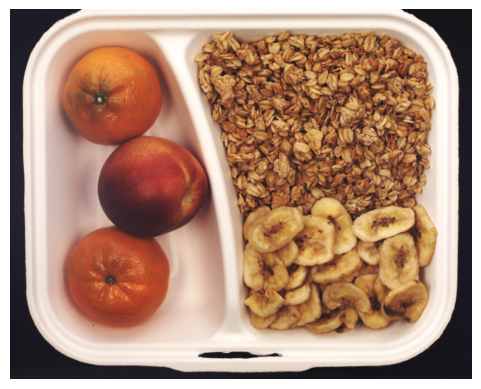

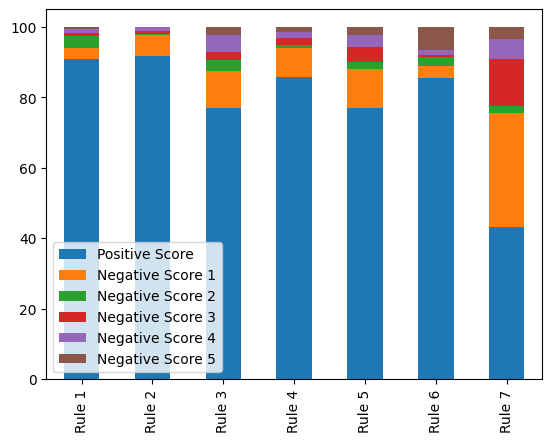

In [14]:
import pandas as pd

df = pd.DataFrame(good_img_probs.T.detach().cpu().numpy()).T
df.index = [f"Rule {i+1}" for i in range(len(df))]
df.columns = ["Positive Score"] + [f"Negative Score {i+1}" for i in range(len(df.columns)-1)]
df_total = df.copy()
df_total['Total'] = df_total.sum(axis=1)
for col in df_total.columns[:-1]:
    df_total[col] = df_total[col] / df_total['Total'] * 100


plt.imshow(Image.open(la_img_path))
plt.axis("off")

df_group_100 = df_total.drop('Total', axis=1)
df_group_100.plot(kind='bar', stacked=True)


In [15]:
rules_for_data[0]

['There must be two mandarins on the left',
 'There must be a peach on the left',
 'There must be oat cereal on the top right',
 'There must be almonds down the right',
 'There must be banana chips down the right',
 'Each content should not overflow.',
 'The amount of banana chips and almonds should be the same.']

In [16]:
print(good_probs_score)
print(la_probs_score)

tensor([0.4312], device='cuda:0')
tensor([0.4303], device='cuda:0')
